In [1]:
import base64
import io
import pickle
import functools
import itertools

import jax.numpy as jnp
import jax
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_debug_key_reuse", True)

# set cache size to 1GB
jax.config.update("jax_compilation_cache_max_size", 2**30 - 1)

# jax.config.update("jax_log_compiles", True)
# jax.config.update("jax_compiler_detailed_logging_min_ops", 50)

# jax.config.update("jax_explain_cache_misses", True)
# jax.config.update("jax_check_tracer_leaks", True)
# jax.config.update("jax_debug_nans", True)

import orthax

import matplotlib
import matplotlib.pyplot as plt
# import matplotlib.animation as animation
import pandas as pd
from scipy.io import loadmat, savemat
from scipy.stats import ranksums

# import plotly.graph_objects as go

from hnmf_tr_optimizer.hnmf_optimizer import HNMFOptimizer, NewHNMFOptimizer, PerturbanceHNMFOptimizer, RedoHNMFOptimizer
from hnmf_tr_optimizer.clusts import result_analysis

# plt.style.use('Solarize_Light2')

# from IPython.display import Markdown, display



ERROR:2025-08-19 21:23:26,617:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 304; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


In [2]:
def scatter_vector(theta, lambda_0=633e-9, n=1.33, radians=False):
    """
    theta - scatter angle
    lambda_0 - lsder wavelength in meters
    n - refractive index of water
    """
    if not radians:
        theta = jnp.radians(theta)
    return (4 * jnp.pi * n/lambda_0) * jnp.sin(theta / 2)

def diffusion_coef(r, k_B=1.38e-23, T=298.15, eta=0.00089):
    """
    r - particle radius
    k_b - Boltzmann constant (J/K)
    T - Temperature (K)
    eta - Viscosity of water at room temerature (Pa*s)
    """
    return k_B * T / (6 * jnp.pi * eta * r)

def prep_data(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1

    g1 = jnp.where(
        jnp.greater_equal(g1_squared, 0),
        jnp.sqrt(g1_squared),
        -jnp.sqrt(-g1_squared)
    )

    # g1 = jnp.sign(g1_squared) * jnp.sqrt(jnp.abs(g1_squared))

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    return q, t, g1

def prep_data_g2(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1
    # g1 = jnp.where(
    #     jnp.greater_equal(g1_squared, 0),
    #     jnp.sqrt(g1_squared),
    #     -jnp.sqrt(-g1_squared)
    # )

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    return q, t, g1_squared

# for drawing normal curves
def normal_distribution_single(x, amplitude, mu, sigma):
    return amplitude * jnp.exp(-(x-mu)**2/(2*sigma**2))/jnp.sqrt(2*jnp.pi*sigma**2)

normal_distributions = jax.vmap(normal_distribution_single, in_axes=(None, 0, 0, 0))

def normal_distribution(possible_D, amp, mu, sig):
    whole = normal_distributions(possible_D, amp, mu, sig).sum(axis=0)
    return whole / jnp.sum(whole) # normalize for plotting


In [3]:


def clean_data_with_svd(runs_data):
    """
    Cleans DLS data by reconstructing it from the first principal component.
    
    Args:
        runs_data: A list of NumPy arrays, where each array is shape
                   (num_angles, num_times).

    Returns:
        A list of cleaned NumPy arrays with the same structure, and U, s for one angle.
    """
    if not runs_data:
        return []

    num_runs = len(runs_data)
    num_angles, num_times = runs_data[0].shape
    
    cleaned_runs_list = [jnp.zeros_like(run) for run in runs_data]
    U_vis, s_vis, Vh_vis = [], [], []

    # Process each angle independently
    for angle_idx in range(num_angles):
        # Assemble the data matrix for this specific angle
        # Shape: (num_times, num_runs)
        M = jnp.stack([run[angle_idx, :] for run in runs_data], axis=1)
        
        # Perform Singular Value Decomposition (SVD)
        U, s, Vh = jax.scipy.linalg.svd(M, full_matrices=False)
        
        # Store components for visualization from a sample angle
        U_vis.append(U)
        s_vis.append(s)
        Vh_vis.append(Vh)

        # Reconstruct the data using ONLY the first component (k=0)
        k = 0
        U_k = U[:, k:k+1]      # Shape: (num_times, 1)
        s_k = s[k:k+1]          # Shape: (1,)
        Vh_k = Vh[k:k+1, :]    # Shape: (1, num_runs)
        
        M_cleaned = U_k @ jnp.diag(s_k) @ Vh_k
        
        # Place the cleaned data back into the list structure
        for run_idx in range(num_runs):
            cleaned_runs_list[run_idx] = cleaned_runs_list[run_idx].at[angle_idx, :].set(M_cleaned[:, run_idx])
            
    return cleaned_runs_list, U_vis, s_vis, Vh_vis


In [4]:
# import some experimental data
q, t, observations_100_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_100nm.csv")
q, t, observations_200_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_200nm.csv")
q, t, observations_500_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_500nm.csv")
q, t, observations_1000_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_1000nm.csv")

q, t, mix_2_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/mix_2.csv")
q, t, mix_1_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/mix_1.csv")
q, t, mix_3_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/mix_3.csv")
q, t, mix_4_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/mix_4.csv")


mix_avg_g2 = jnp.mean(jnp.stack([mix_1_g2, mix_2_g2, mix_3_g2, mix_4_g2]), axis=0)

Data generation and cleaning complete.
The 'cleaned_runs' variable is a list of 4 NumPy arrays,
each with shape (25, 165), containing the denoised data.


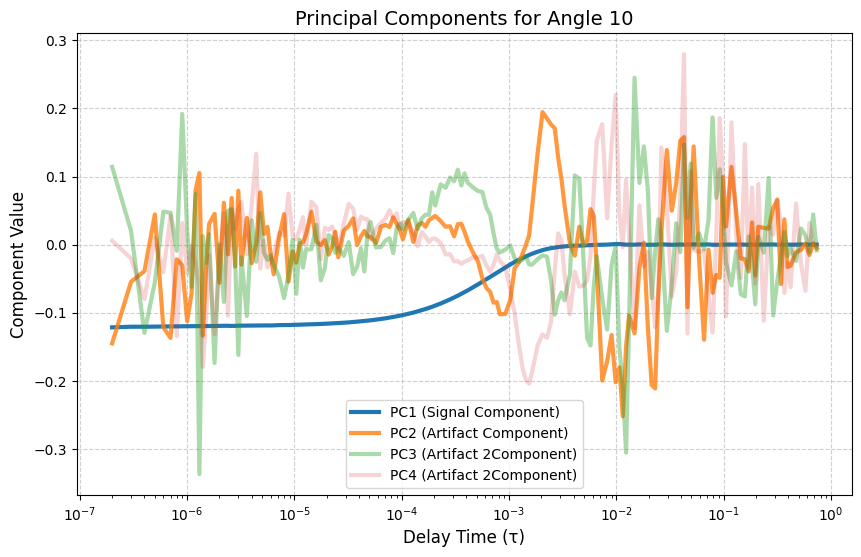

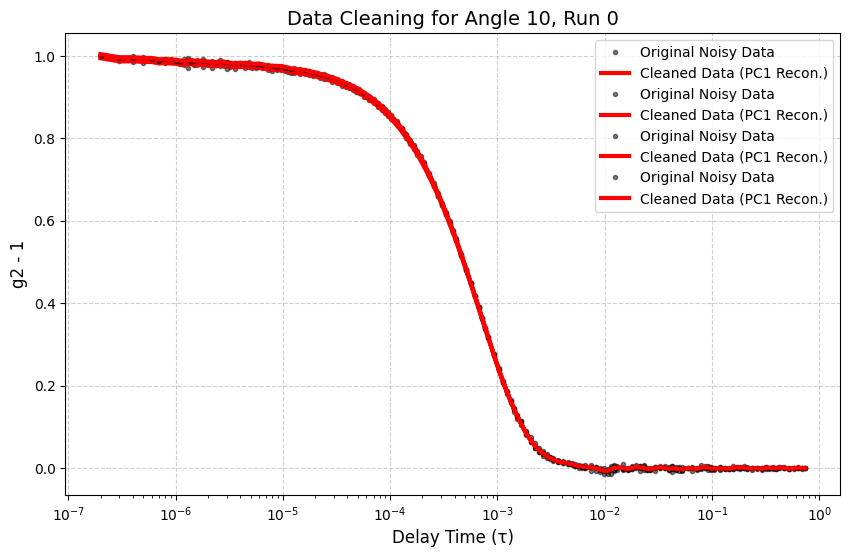

In [48]:
# Generate the data
original_runs = [
    mix_1_g2,
    mix_2_g2,
    mix_3_g2,
    mix_4_g2
]
# original_runs = [
#     observations_100_g2,
#     observations_200_g2,
#     observations_500_g2,
#     observations_1000_g2,
# ]
# Clean the data
cleaned_runs, U_for_plot, s_for_plot, vh_for_plot = clean_data_with_svd(original_runs)

# --- Visualize the results for a single angle to verify ---
angle_to_plot = 10 # Pick a middle angle


# a) Plot the first two principal components (the basis shapes)
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.title(f"Principal Components for Angle {angle_to_plot}", fontsize=14)
plt.plot(t, U_for_plot[angle_to_plot][:, 0], label='PC1 (Signal Component)', lw=3)
plt.plot(t, U_for_plot[angle_to_plot][:, 1], label='PC2 (Artifact Component)', lw=3, alpha=0.8)
plt.plot(t, U_for_plot[angle_to_plot][:, 2], label='PC3 (Artifact 2Component)', lw=3, alpha=0.4)
plt.plot(t, U_for_plot[angle_to_plot][:, 3], label='PC4 (Artifact 2Component)', lw=3, alpha=0.2)
plt.xlabel("Delay Time (τ)", fontsize=12)
plt.ylabel("Component Value", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("pca_components.png")

# b) Compare original vs. cleaned data for one run
run_to_plot = 0
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.title(f"Data Cleaning for Angle {angle_to_plot}, Run {run_to_plot}", fontsize=14)
for run_to_plot in range(len(original_runs)):
    plt.plot(t, original_runs[run_to_plot][angle_to_plot, :], 'k.', label='Original Noisy Data', alpha=0.5)
    plt.plot(t, cleaned_runs[run_to_plot][angle_to_plot, :], 'r-', label='Cleaned Data (PC1 Recon.)', lw=3)
plt.xlabel("Delay Time (τ)", fontsize=12)
plt.ylabel("g2 - 1", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("data_cleaning_comparison.png")

print("Data generation and cleaning complete.")
print(f"The 'cleaned_runs' variable is a list of {len(cleaned_runs)} NumPy arrays,")
print(f"each with shape {cleaned_runs[0].shape}, containing the denoised data.")

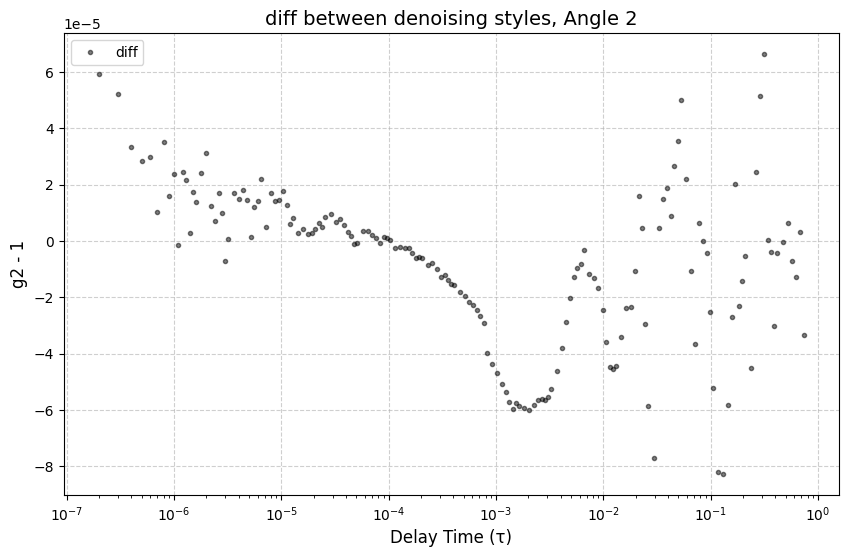

In [50]:
# mix_avg_g2
angle_to_plot = 2
recon = jnp.stack([U_for_plot[angle_to_plot][:, 0] * jnp.mean((vh_for_plot[angle_to_plot].T * s_for_plot[angle_to_plot])[:, 0]) for angle_to_plot in range(len(U_for_plot))])
# s_for_plot[0]


plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.title(f"diff between denoising styles, Angle {angle_to_plot}", fontsize=14)
# plt.plot(t, mix_avg_g2[angle_to_plot], 'k.', label='averaged signal', alpha=0.5)
# plt.plot(t, recon[angle_to_plot], 'r-', label='mean PC1', lw=3)
plt.plot(t, mix_avg_g2[angle_to_plot] - recon[angle_to_plot], 'k.', label='diff', alpha=0.5)
plt.xlabel("Delay Time (τ)", fontsize=12)
plt.ylabel("g2 - 1", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("data_cleaning_comparison.png")



In [51]:
### models

SCALING_CONST = 2.45e-7


######### Normal model ##########

def get_g1(t, nk, a, c):
    b = a**2/2
    d = jnp.sqrt(2)
    s_pi = jnp.sqrt(jnp.pi)
    x = (-a + c*t)/d
    y = jnp.where(
        jnp.greater_equal(x, 5),
        1/(x*s_pi),
        jax.scipy.special.erfc(x)*jnp.exp(x**2)
    )
    e = (nk/2)*jnp.exp(-b)
    return e*y

# vectorize along time dimension
all_g1 = jax.vmap(
    get_g1,
    in_axes=(0, None, None, None)
)

def source3_1(t, q, amp, mu, sig):
    ################
    const = SCALING_CONST
    # const = 1.0
    ################
    nk = amp
    sig = sig*const
    mu = mu*const
    a = mu/sig
    c = q**2*sig

    g = all_g1(t, nk, a, c)
    return g

by_Xs1 = jax.vmap(
    source3_1,
    in_axes=(None, None, 0, 0, 0)
)

source_matrix1 = jax.vmap(
    by_Xs1,
    in_axes=(None, 0, None, None, None)
)

def g1_matrix(q, t, amp, mu, sig):
    full = source_matrix1(t, q, amp, mu, sig)
    full = jnp.sum(full, axis=1)
    return full

def g2_minus1_matrix(q, t, amp, mu, sig, beta):
    g1 = g1_matrix(q, t, amp, mu, sig)
    g2_minus1 = beta * g1**2
    return g2_minus1

######### Dirac model ##########

def single_exp(q, t, D, amp):
    return amp * jnp.exp(-D * q**2 * t)

by_Xs = jax.vmap(
    single_exp,
    in_axes=(None, None, 0, 0)
)

by_t = jax.vmap(
    by_Xs,
    in_axes=(None, 0, None, None)
)

by_q = jax.vmap(
    by_t,
    in_axes=(0, None, None, None)
)

def g1_dirac(q, t, D, amp, const):
    D_ = D * const
    full = by_q(q, t, D_, amp)
    full = jnp.sum(full, axis=2)
    return full

def g2_minus1_matrix_dirac(q, t, D, amp, beta, const):
    amp = amp / jnp.sum(amp)
    g1 = g1_dirac(q, t, D, amp, const)
    g2_minus1 = beta * g1**2
    return g2_minus1


def gen_bounds_dirac(k):
    return (1e-9*jnp.ones(k),1e-9*jnp.ones(k),jnp.array([0.0])), (1e-3*jnp.ones(k), jnp.ones(k),jnp.array([1.0]))



In [52]:
### Optimizers
min_k = 1
max_k = 2


# small_particle_bound = 1e-10 # 1 angstrom
# large_particle_bound = 1e-5 # 10 microns
def gen_bounds_std(num_sources):
    lower_bounds = (
        1e-9*jnp.ones(num_sources),
        jnp.array([1e-9])
    )
    upper_bounds = (
        1e-3*jnp.ones(num_sources),
        jnp.array([1.0])
    )
    return lower_bounds, upper_bounds

def gen_bounds_std_g1(num_sources):
    lower_bounds = (
        1e-9*jnp.ones(num_sources),
    )
    upper_bounds = (
        1e-3*jnp.ones(num_sources),
    )
    return lower_bounds, upper_bounds


def gen_bounds_normal_g1(num_sources):
    lower_bounds = (
        1e-9*jnp.ones(num_sources),
        1e-9*jnp.ones(num_sources),
        1e-9*jnp.ones(num_sources),
    )
    upper_bounds = (
        jnp.inf*jnp.ones(num_sources),
        1e-3*jnp.ones(num_sources),
        1e-3*jnp.ones(num_sources),
    )
    return lower_bounds, upper_bounds

def extract_point(row):
    # extract source amplitudes and positions to use as points for clustering
    points = []
    sol = row['sol']
    D = sol[0]
    amp = sol[1]
    beta = sol[2]
    if isinstance(amp, float):
        D = jnp.array([D])
        amp = jnp.array([amp])
        beta = jnp.array([beta])
    else:
        D = jnp.array(D)
        amp = jnp.array(amp)
        beta = jnp.array(beta)
    amp = amp/jnp.sum(amp)
    for p in range(len(amp)):
        point = jnp.stack([D[p], amp[p], beta[p]]).tolist()
        points.append(point)
    return points

def clustering_preprocess(res):
    res = res.copy().groupby('num_sources', group_keys=False)[res.columns.tolist()].apply(filter_quantile)
    res['points'] = res.apply(extract_point, axis=1)
    return res

def filter_quantile(res, col_to_filter='fval', quantile=0.25):
    mod_col = res[col_to_filter].apply(lambda x: jnp.inf if jnp.isnan(x) else x)
    return res[
        mod_col < mod_col.quantile(q=quantile)
    ]

def process_res_dirac_(all_res, obs_size):
    Forclusts = clustering_preprocess(all_res)
    Forclusts = Forclusts.groupby('num_sources', group_keys=False)[Forclusts.columns.tolist()].apply(lambda group: result_analysis(
        group['points'].sum(),
        # group['normF'].mean(),
        group['fval'].mean(),
        obs_size,
        group['num_sources'].iloc[0]
    ))
    Forclusts = Forclusts.set_index('num_source')

    return Forclusts



def extract_point_std(row):
    # extract source amplitudes and positions to use as points for clustering
    points = []
    sol = row['sol']
    sig = sol[0]
    beta = sol[1]
    beta = jnp.array(beta)
    if isinstance(sig, float):
        sig = jnp.array([sig])
    else:
        sig = jnp.array(sig)
    for p in range(len(sig)):
        point = sig.reshape(-1, 1)[p].tolist()
        points.append(point)
    return points

def clustering_preprocess_std(res):
    res = res.copy().groupby('num_sources', group_keys=False)[res.columns.tolist()].apply(filter_quantile)
    res['points'] = res.apply(extract_point_std, axis=1)
    return res

def process_res_std_(all_res, obs_size):
    Forclusts = clustering_preprocess_std(all_res)
    Forclusts = Forclusts.groupby('num_sources', group_keys=False)[Forclusts.columns.tolist()].apply(lambda group: result_analysis(
        group['points'].sum(),
        # group['normF'].mean(),
        group['fval'].mean(),
        obs_size,
        group['num_sources'].iloc[0]
    ))
    Forclusts = Forclusts.set_index('num_source')

    return Forclusts

def extract_point_std_g1(row):
    # extract source amplitudes and positions to use as points for clustering
    points = []
    sol = row['sol']
    sig = sol[0]
    if isinstance(sig, float):
        sig = jnp.array([sig])
    else:
        sig = jnp.array(sig)
    for p in range(len(sig)):
        point = sig.reshape(-1, 1)[p].tolist()
        points.append(point)
    return points

def clustering_preprocess_std_g1(res):
    res = res.copy().groupby('num_sources', group_keys=False)[res.columns.tolist()].apply(filter_quantile)
    res['points'] = res.apply(extract_point_std_g1, axis=1)
    return res

def process_res_std_g1_(all_res, obs_size):
    Forclusts = clustering_preprocess_std_g1(all_res)
    Forclusts = Forclusts.groupby('num_sources', group_keys=False)[Forclusts.columns.tolist()].apply(lambda group: result_analysis(
        group['points'].sum(),
        # group['normF'].mean(),
        group['fval'].mean(),
        obs_size,
        group['num_sources'].iloc[0]
    ))
    Forclusts = Forclusts.set_index('num_source')

    return Forclusts

# from dls_model import clustering_preprocess as clustering_preprocess_std_normal

def extract_point_std_normal(row):
    # extract source amplitudes and positions to use as points for clustering
    points = []
    sol = row['sol']
    amp = sol[0]
    mu = sol[1]
    sig = sol[2]
    for p in range(len(amp)):
        point = jnp.stack([amp[p], mu[p], sig[p]]).tolist()
        points.append(point)        
    return points


def clustering_preprocess_std_normal(res):
    res = res.copy().groupby('num_sources', group_keys=False)[res.columns.tolist()].apply(filter_quantile)
    res['points'] = res.apply(extract_point_std_normal, axis=1)
    return res

def process_res_normal_(all_res, obs_size):
    Forclusts = clustering_preprocess_std_normal(all_res)
    Forclusts = Forclusts.groupby('num_sources', group_keys=False)[Forclusts.columns.tolist()].apply(lambda group: result_analysis(
        group['points'].sum(),
        # group['normF'].mean(),
        group['fval'].mean(),
        obs_size,
        group['num_sources'].iloc[0]
    ))
    Forclusts = Forclusts.set_index('num_source')

    return Forclusts

def l_statistic(full_sols, clust_info, sill_threshold=0.6, p_threshold=0.05):
    p_values = {}
    errors = {}
    n_opt = 1
    for k in clust_info[clust_info['min_sillhouette_score'] > sill_threshold].index:
        current_errors = full_sols[full_sols['num_sources'] == k]['normF'].sort_values().to_list()
        errors[k] = current_errors

        # For the second valid k onwards, perform the statistical test
        if k > 1:
            # Get the errors from the previous valid k
            prev_errors = errors[k-1]
            
            # Wilcoxon rank-sum test to see if the new errors are significantly smaller
            # We use a one-sided test ('less') to check if the current error distribution
            # is stochastically less than the previous one.
            _, p_val = ranksums(current_errors, prev_errors, alternative='less')
            p_values[k] = p_val
            
            # If the result is significant, this k is a better model
            if p_val < p_threshold:
                n_opt = k
    return n_opt, p_values, errors

def l_statistic2(full_sols, clust_info, observations, q, t, sill_threshold=0.6, p_threshold=0.05):
    p_values = {}
    errors = {}
    n_opt = 1
    for k in clust_info[clust_info['min_sillhouette_score'] > sill_threshold].index:
        best_amp, best_D, best_sig, best_beta = full_sols[full_sols['num_sources'] == k].sort_values('fval').iloc[0]['sol']
        recon = g2_minus1_matrix(q, t, best_amp, best_D, best_sig, best_beta)
        current_errors = jnp.zeros(len(q))
        # current_errors = []
        for qs in range(len(q)):
            s_segment = observations[qs, :]
            shat_segment = recon[qs, :]
            
            # Calculate the relative vector norm (error)
            error_norm = jnp.linalg.norm(shat_segment - s_segment)
            signal_norm = jnp.linalg.norm(s_segment)
            # Avoid division by zero if a signal segment is all zeros
            current_errors = current_errors.at[qs].set(error_norm / signal_norm if signal_norm > 0 else 0)

        errors[k] = current_errors


        # For the second valid k onwards, perform the statistical test
        if k > 1:
            # Get the errors from the previous valid k
            prev_errors = errors[k-1]
            
            # Wilcoxon rank-sum test to see if the new errors are significantly smaller
            # We use a one-sided test ('less') to check if the current error distribution
            # is stochastically less than the previous one.
            _, p_val = ranksums(current_errors, prev_errors, alternative='less')
            p_values[k] = p_val
            
            # If the result is significant, this k is a better model
            if p_val < p_threshold:
                n_opt = k
    return n_opt, p_values, errors

In [53]:
process_res_dirac = functools.partial(process_res_dirac_, obs_size=mix_1_g2.size)
process_res_std = functools.partial(process_res_std_, obs_size=mix_1_g2.size)
process_res_std_g1 = functools.partial(process_res_std_g1_, obs_size=mix_1_g2.size)
process_res_normal = functools.partial(process_res_normal_, obs_size=mix_1_g2.size)

In [54]:
# set up the multi-phase optimization
class InitParamsGenerator2:
    def __init__(self, bound_generator, seed=42):
        self.bound_generator = bound_generator
        self.key = jax.random.PRNGKey(seed)
    
    def __call__(self, num_sources):
        lb, ub = self.bound_generator(num_sources)
        num_params = len(lb)
        init = []
        for i in range(num_params):
            self.key, subkey = jax.random.split(self.key)
            lb_i = jnp.array(lb[i])
            ub_i = jnp.array(ub[i])
            generated = jax.random.uniform(subkey, lb_i.shape, minval=lb_i, maxval=ub_i)
            unbounded_upper_gen = jax.random.uniform(subkey, lb_i.shape, minval=lb_i)
            unbounded_lower_gen = jax.random.uniform(subkey, lb_i.shape, maxval=ub_i)
            generated = jnp.where(
                jnp.isposinf(generated),
                unbounded_upper_gen,
                generated
            )
            generated = jnp.where(
                jnp.isneginf(generated),
                unbounded_lower_gen,
                generated
            )
            init.append(generated)
        return tuple(init)

optimizer_dirac_single = NewHNMFOptimizer(
# optimizer_dirac_single = PerturbanceHNMFOptimizer(
    model_fn=g2_minus1_matrix_dirac,
    param_generator=InitParamsGenerator2(gen_bounds_dirac),
    bound_generator=gen_bounds_dirac,
    input_args = ('q', 't'),
    param_args=('D', 'amp', 'beta'),
    constants = {"const": SCALING_CONST},
    min_k=min_k,
    max_k=max_k,
    nsim=100
)


def gen_bounds_normal_std(num_sources):
    lower_bounds = (
        # 1e-9*jnp.ones(num_sources),
        # 1e-9*jnp.ones(num_sources),
        1e-9*jnp.ones(num_sources),
        # jnp.array([0.0])
    )
    upper_bounds = (
        # jnp.inf*jnp.ones(num_sources),
        # 1e-3*jnp.ones(num_sources),
        1e-3*jnp.ones(num_sources),
        # jnp.array([1.0])
    )
    return lower_bounds, upper_bounds

std_opts = {}
for k in range(min_k, max_k + 1):
    std_opt = NewHNMFOptimizer(
        model_fn=g2_minus1_matrix,
        param_generator=InitParamsGenerator2(gen_bounds_normal_std),
        bound_generator=gen_bounds_normal_std,
        input_args = ('q', 't', 'amp', 'mu', 'beta'),
        param_args=('sig',),
        constants = {},
        min_k=k,
        max_k=k,
        nsim=20
    )
    std_opts[k] = (std_opt)


def gen_bounds_normal_final(num_sources):
    lower_bounds = (
        1e-9*jnp.ones(num_sources),
        1e-9*jnp.ones(num_sources),
        1e-9*jnp.ones(num_sources),
        jnp.array([0.0])
    )
    upper_bounds = (
        jnp.inf*jnp.ones(num_sources),
        1e-3*jnp.ones(num_sources),
        1e-3*jnp.ones(num_sources),
        jnp.array([1.0])
    )
    return lower_bounds, upper_bounds

final_opt = NewHNMFOptimizer(
# final_opt = PerturbanceHNMFOptimizer(
    # model_fn=g1_matrix,
    model_fn=g2_minus1_matrix,
    param_generator=InitParamsGenerator2(gen_bounds_normal_final),
    bound_generator=gen_bounds_normal_final,
    input_args = ('q', 't'),
    param_args=('amp', 'mu', 'sig', 'beta'),
    constants = {},
    min_k=min_k,
    max_k=max_k,
    nsim=100
)


inputs = (q, t)
opt_options = {
    'fatol': 1e-14,
    'frtol': 0,
    'maxiter': 2000,
    'gatol': 1e-12
}

class InitParamFeeder:
    def __init__(self, params_list_map):
        self.params_list_map = params_list_map
        self.counter = {k: 0 for k in params_list_map.keys()}

    def __call__(self, num_sources):
        params = self.params_list_map[num_sources][self.counter[num_sources]]
        self.counter[num_sources] += 1
        return params



In [55]:

observations = recon
rand_key = jax.random.key(495)



# phase 1 - fit dirac model, gives centers and amplitudes
g2_res = optimizer_dirac_single((q, t), observations, opt_options=opt_options)
clust_sol = process_res_dirac(g2_res)

print("finished phase 1 for pair")


# dirac_sols.append((D, amp, beta))

# phase 2 - convert dirac to normal, only fit the standard deviation of the gaussians
# centers and amplitudes are taken from the first phase and fixed

params_to_feed = {}
for k in clust_sol.index:
    D, amp, betas = clust_sol.loc[k]['centers']
    if not isinstance(D, jnp.ndarray):
        D = jnp.array(D, ndmin=1)
    if not isinstance(amp, jnp.ndarray):
        amp = jnp.array(amp, ndmin=1)
    if not isinstance(betas, jnp.ndarray):
        betas = jnp.array(betas, ndmin=1)
    beta = betas[0:1]
    std_sols = std_opts[k]((q, t, amp, D, beta), observations, opt_options=opt_options)
    sig_sol = process_res_std_g1(std_sols)['centers'].iloc[0][0]
    if not isinstance(sig_sol, jnp.ndarray):
        sig_sol = jnp.array(sig_sol, ndmin=1)

    nsim = 100
    params_to_feed[k] = []
    for j in range(nsim):
        rand_key, subkey1, subkey2, subkey3 = jax.random.split(rand_key, 4)
        D_ = D + jax.random.normal(subkey1, D.shape) * 0.05 * D
        sig_ = sig_sol + jax.random.normal(subkey2, sig_sol.shape) * 0.05 * sig_sol
        amp_ = amp + jax.random.normal(subkey3, amp.shape) * 0.05 * amp
        params_to_feed[k].append((amp_, D_, sig_, beta))

print("finished phase 2 for pair")

# final phase - fit with all parameters free

final_opt.reset_param_generator(InitParamFeeder(params_to_feed))

final_g2_sols = final_opt((q, t), observations, opt_options=opt_options)
final_clust_sol = process_res_normal(final_g2_sols)

print("\n\n~~~Done~~~")

SIMULATIONS FOR 1 SOURCES TOOK 4.90009069442749 SECONDS
SIMULATIONS FOR 2 SOURCES TOOK 6.015904426574707 SECONDS
Clustering  2
finished phase 1 for pair
SIMULATIONS FOR 1 SOURCES TOOK 2.9450900554656982 SECONDS
SIMULATIONS FOR 2 SOURCES TOOK 4.764877796173096 SECONDS
Clustering  2
finished phase 2 for pair
SIMULATIONS FOR 1 SOURCES TOOK 3.921957492828369 SECONDS
SIMULATIONS FOR 2 SOURCES TOOK 26.425594329833984 SECONDS
Clustering  2


~~~Done~~~


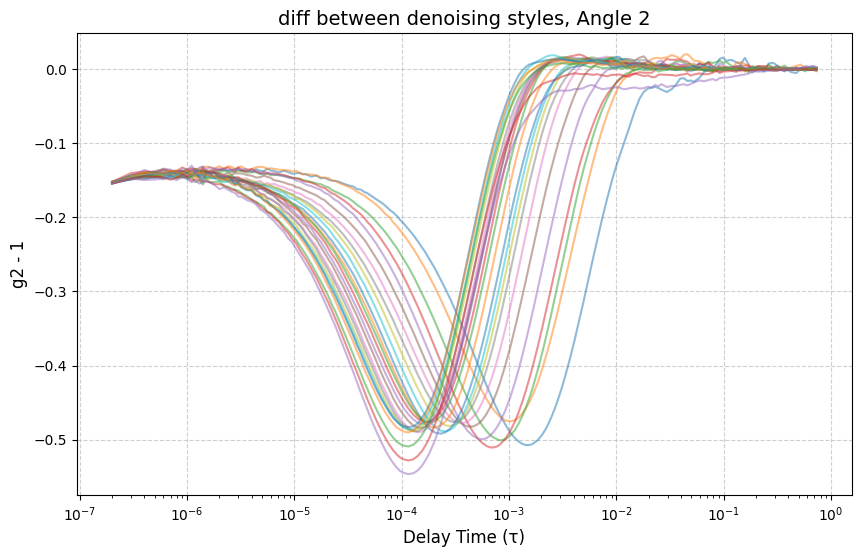

In [56]:
amp, mu, sig = final_clust_sol['centers'].loc[2]
pred = g2_minus1_matrix(q, t, amp, mu, sig, beta)


plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.title(f"diff between denoising styles, Angle {angle_to_plot}", fontsize=14)
# plt.plot(t, mix_avg_g2[angle_to_plot], 'k.', label='averaged signal', alpha=0.5)
# plt.plot(t, recon[angle_to_plot], 'r-', label='mean PC1', lw=3)
for angle_to_plot in range(len(mix_avg_g2)):
    plt.plot(t, pred[angle_to_plot] - recon[angle_to_plot], label='diff', alpha=0.5)
plt.xlabel("Delay Time (τ)", fontsize=12)
plt.ylabel("g2 - 1", fontsize=12)
# plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("data_cleaning_comparison.png")




In [57]:

observations = mix_avg_g2
rand_key = jax.random.key(495)



# phase 1 - fit dirac model, gives centers and amplitudes
g2_res = optimizer_dirac_single((q, t), observations, opt_options=opt_options)
clust_sol = process_res_dirac(g2_res)

print("finished phase 1 for pair")


# dirac_sols.append((D, amp, beta))

# phase 2 - convert dirac to normal, only fit the standard deviation of the gaussians
# centers and amplitudes are taken from the first phase and fixed

params_to_feed = {}
for k in clust_sol.index:
    D, amp, betas = clust_sol.loc[k]['centers']
    if not isinstance(D, jnp.ndarray):
        D = jnp.array(D, ndmin=1)
    if not isinstance(amp, jnp.ndarray):
        amp = jnp.array(amp, ndmin=1)
    if not isinstance(betas, jnp.ndarray):
        betas = jnp.array(betas, ndmin=1)
    beta = betas[0:1]
    std_sols = std_opts[k]((q, t, amp, D, beta), observations, opt_options=opt_options)
    sig_sol = process_res_std_g1(std_sols)['centers'].iloc[0][0]
    if not isinstance(sig_sol, jnp.ndarray):
        sig_sol = jnp.array(sig_sol, ndmin=1)

    nsim = 100
    params_to_feed[k] = []
    for j in range(nsim):
        rand_key, subkey1, subkey2, subkey3 = jax.random.split(rand_key, 4)
        D_ = D + jax.random.normal(subkey1, D.shape) * 0.05 * D
        sig_ = sig_sol + jax.random.normal(subkey2, sig_sol.shape) * 0.05 * sig_sol
        amp_ = amp + jax.random.normal(subkey3, amp.shape) * 0.05 * amp
        params_to_feed[k].append((amp_, D_, sig_, beta))

print("finished phase 2 for pair")

# final phase - fit with all parameters free

final_opt.reset_param_generator(InitParamFeeder(params_to_feed))

final_g2_sols2 = final_opt((q, t), observations, opt_options=opt_options)
final_clust_sol2 = process_res_normal(final_g2_sols2)

print("\n\n~~~Done~~~")

SIMULATIONS FOR 1 SOURCES TOOK 2.4231479167938232 SECONDS
SIMULATIONS FOR 2 SOURCES TOOK 3.085453987121582 SECONDS
Clustering  2
finished phase 1 for pair
SIMULATIONS FOR 1 SOURCES TOOK 0.21361970901489258 SECONDS
SIMULATIONS FOR 2 SOURCES TOOK 4.767571687698364 SECONDS
Clustering  2
finished phase 2 for pair
SIMULATIONS FOR 1 SOURCES TOOK 1.0832679271697998 SECONDS
SIMULATIONS FOR 2 SOURCES TOOK 26.085408210754395 SECONDS
Clustering  2


~~~Done~~~


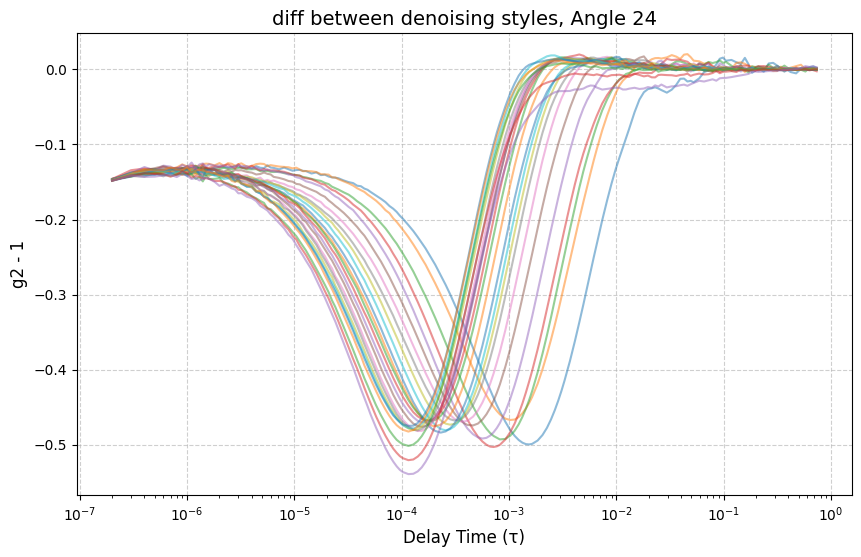

In [ ]:
amp, mu, sig = final_clust_sol2['centers'].loc[2]
pred = g2_minus1_matrix(q, t, amp, mu, sig, beta)


plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.title(f"diff between denoising styles, Angle {angle_to_plot}", fontsize=14)
# plt.plot(t, mix_avg_g2[angle_to_plot], 'k.', label='averaged signal', alpha=0.5)
# plt.plot(t, recon[angle_to_plot], 'r-', label='mean PC1', lw=3)
for angle_to_plot in range(len(mix_avg_g2)):
    plt.plot(t, pred[angle_to_plot] - recon[angle_to_plot], label='diff', alpha=0.5)
plt.xlabel("Delay Time (τ)", fontsize=12)
plt.ylabel("g2 - 1", fontsize=12)
# plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("data_cleaning_comparison.png")




In [32]:

observations = mix_1_g2
rand_key = jax.random.key(495)



# phase 1 - fit dirac model, gives centers and amplitudes
g2_res = optimizer_dirac_single((q, t), observations, opt_options=opt_options)
clust_sol = process_res_dirac(g2_res)

print("finished phase 1 for pair")


# dirac_sols.append((D, amp, beta))

# phase 2 - convert dirac to normal, only fit the standard deviation of the gaussians
# centers and amplitudes are taken from the first phase and fixed

params_to_feed = {}
for k in clust_sol.index:
    D, amp, betas = clust_sol.loc[k]['centers']
    if not isinstance(D, jnp.ndarray):
        D = jnp.array(D, ndmin=1)
    if not isinstance(amp, jnp.ndarray):
        amp = jnp.array(amp, ndmin=1)
    if not isinstance(betas, jnp.ndarray):
        betas = jnp.array(betas, ndmin=1)
    beta = betas[0:1]
    std_sols = std_opts[k]((q, t, amp, D, beta), observations, opt_options=opt_options)
    sig_sol = process_res_std_g1(std_sols)['centers'].iloc[0][0]
    if not isinstance(sig_sol, jnp.ndarray):
        sig_sol = jnp.array(sig_sol, ndmin=1)

    nsim = 100
    params_to_feed[k] = []
    for j in range(nsim):
        rand_key, subkey1, subkey2, subkey3 = jax.random.split(rand_key, 4)
        D_ = D + jax.random.normal(subkey1, D.shape) * 0.05 * D
        sig_ = sig_sol + jax.random.normal(subkey2, sig_sol.shape) * 0.05 * sig_sol
        amp_ = amp + jax.random.normal(subkey3, amp.shape) * 0.05 * amp
        params_to_feed[k].append((amp_, D_, sig_, beta))

print("finished phase 2 for pair")

# final phase - fit with all parameters free

final_opt.reset_param_generator(InitParamFeeder(params_to_feed))

final_g2_sols3 = final_opt((q, t), observations, opt_options=opt_options)
final_clust_sol3 = process_res_normal(final_g2_sols3)

print("\n\n~~~Done~~~")

SIMULATIONS FOR 1 SOURCES TOOK 2.9152064323425293 SECONDS
SIMULATIONS FOR 2 SOURCES TOOK 3.3329081535339355 SECONDS
Clustering  2
finished phase 1 for pair
SIMULATIONS FOR 1 SOURCES TOOK 3.6411280632019043 SECONDS
SIMULATIONS FOR 2 SOURCES TOOK 21.054307460784912 SECONDS
Clustering  2
finished phase 2 for pair
SIMULATIONS FOR 1 SOURCES TOOK 0.9999854564666748 SECONDS
SIMULATIONS FOR 2 SOURCES TOOK 83.2164659500122 SECONDS
Clustering  2


~~~Done~~~
